In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

### Dataset Overview

- Number of observations: 297
- Number of features: 15
- Target variable: target (converted to binary disease)

In [3]:
columns= ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 
           'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv("C:/Users/moham/Desktop/ml-eda-project/data/processed.cleveland.data", names= columns)
df.head(100)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,52.0,1.0,4.0,128.0,255.0,0.0,0.0,161.0,1.0,0.0,1.0,1.0,7.0,1
96,59.0,1.0,4.0,110.0,239.0,0.0,2.0,142.0,1.0,1.2,2.0,1.0,7.0,2
97,60.0,0.0,4.0,150.0,258.0,0.0,2.0,157.0,0.0,2.6,2.0,2.0,7.0,3
98,52.0,1.0,2.0,134.0,201.0,0.0,0.0,158.0,0.0,0.8,1.0,1.0,3.0,0


In [4]:
# Check missing values
print(df.info()) # Found "?" in some columns (ca and thal)
print((df == '?').sum())
df = df.replace('?', np.nan)
df = df.apply(pd.to_numeric)
df = df.dropna()





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB
None
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype:

### Q1. Is the dataset balanced between patients with and without heart disease?

<Figure size 1400x600 with 0 Axes>

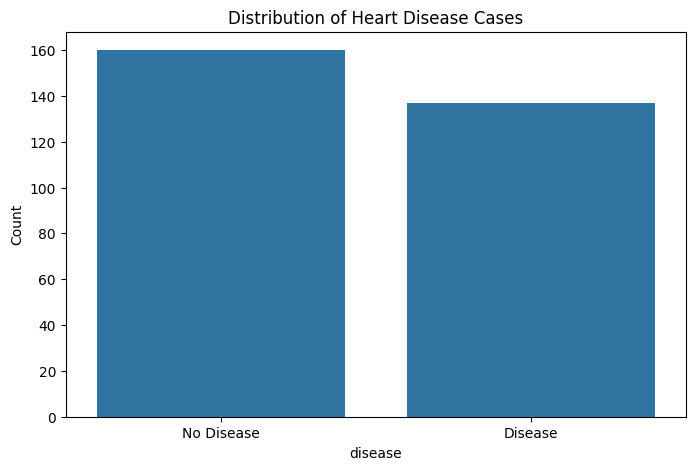

disease
0    53.87
1    46.13
Name: proportion, dtype: float64


In [5]:
df['disease'] = (df['target'] > 0).astype(int)

plt.figure(figsize=(14, 6))


plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="disease")
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.title('Distribution of Heart Disease Cases')
plt.ylabel('Count')
plt.show()

disease_counts = df['disease'].value_counts(normalize=True)*100
print(disease_counts.round(2))


**Interpretation:**

- The dataset contains 54% patients without heart disease and 46% with heart disease.
- The classes are balanced.


### Q2. How does age distribution differ between patients with and without heart disease?

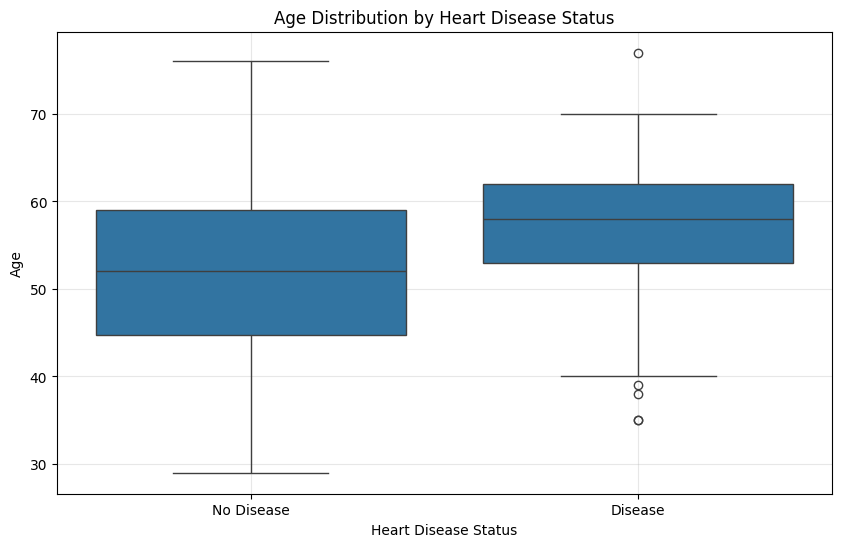

Average Age:
  No Disease: 52.6
  Disease:    56.8


In [6]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='disease', y='age')
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Heart Disease Status')
plt.ylabel('Age')
plt.grid(True, alpha=0.3)

plt.show()

healthy_age = df[df['disease'] == 0]['age']
diseased_age = df[df['disease'] == 1]['age']

print("Average Age:")
print(f"  No Disease: {healthy_age.mean():.1f}")
print(f"  Disease:    {diseased_age.mean():.1f}")





### Q3. Is heart disease more prevalent in males or females?

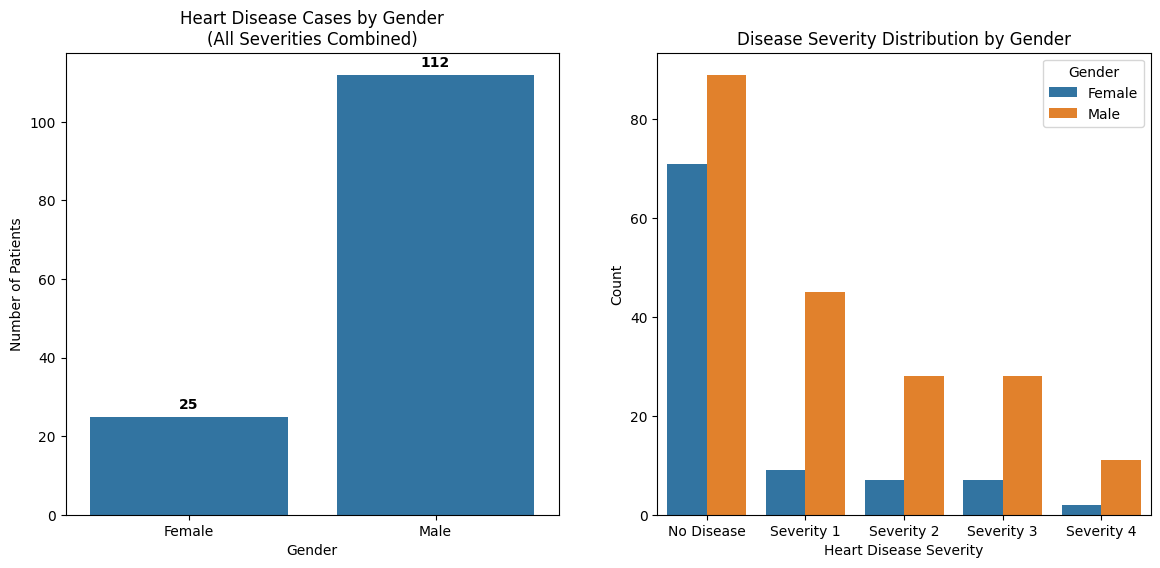

Female prevalence: 26.04%
Male prevanlence: 55.72%


In [7]:
plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
disease_df = df[df['target'] > 0]  
sns.countplot(data=disease_df, x='sex')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'])
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.title('Heart Disease Cases by Gender\n(All Severities Combined)')

for i, count in enumerate(disease_df['sex'].value_counts().sort_index()):
    plt.text(i, count + 2, str(count), ha='center', fontweight='bold')

plt.subplot(1, 2, 2)

sns.countplot(data=df, x='target', hue='sex')
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['No Disease', 'Severity 1', 'Severity 2', 'Severity 3', 'Severity 4'])
plt.xlabel('Heart Disease Severity')
plt.ylabel('Count')
plt.title('Disease Severity Distribution by Gender')
plt.legend(['Female', 'Male'], title='Gender')
plt.show()

gender_disease_rate = df.groupby('sex')['disease'].mean()*100

print(f"Female prevalence: {gender_disease_rate[0]:.2f}%")
print(f"Male prevanlence: {gender_disease_rate[1]:.2f}%")


**Interpretation:**

- The prevalence of heart disease is higher in males than females.
- This suggests gender may be an important factor associated with heart disease risk.


### Q4. How does age interact with gender in heart disease occurrence?

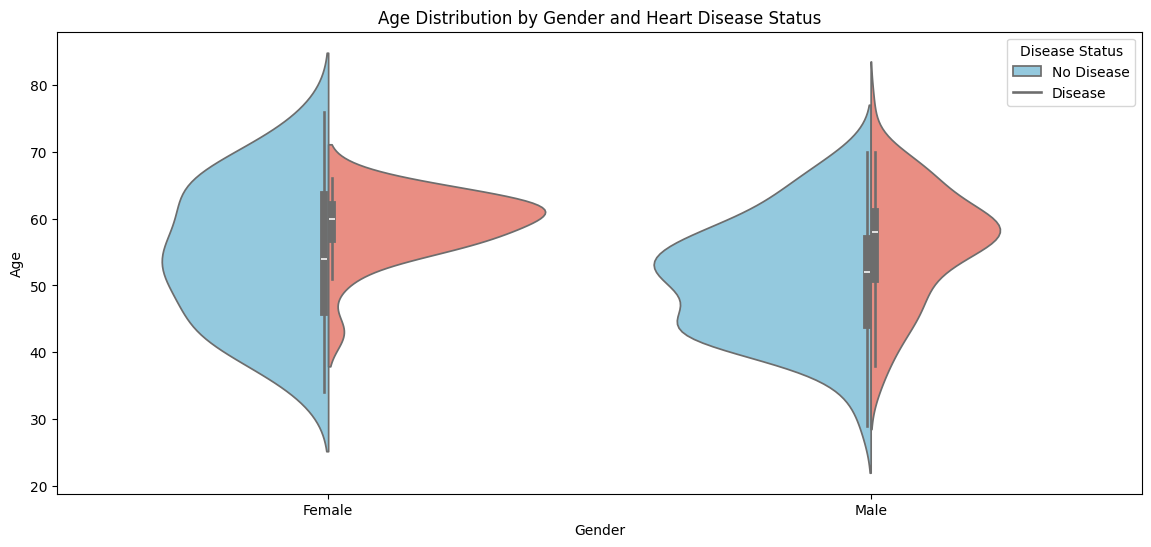

sex  disease
0.0  0          54.58
     1          59.08
1.0  0          51.10
     1          56.24
Name: age, dtype: float64


In [8]:
plt.figure(figsize=(14, 6))

sns.violinplot(data=df, x='sex', y='age', hue='disease', split=True, palette={0: "skyblue", 1: "salmon"})

plt.xticks([0, 1], ['Female', 'Male'])
plt.xlabel("Gender")
plt.ylabel("Age")
plt.title("Age Distribution by Gender and Heart Disease Status")

plt.legend(title='Disease Status', labels=['No Disease', 'Disease'])

plt.show()

interaction_stats = df.groupby(['sex', 'disease'])['age'].mean()
print(interaction_stats.round(2))



**Interpretation:**

- In both males and females, patients with heart disease are older on average.
- The age difference is slightly larger in males (~5 years) compared to females (~4.5 years).
- This suggests that age is positively associated with heart disease across both genders.


### Q5. Which chest pain types are most associated with heart disease?

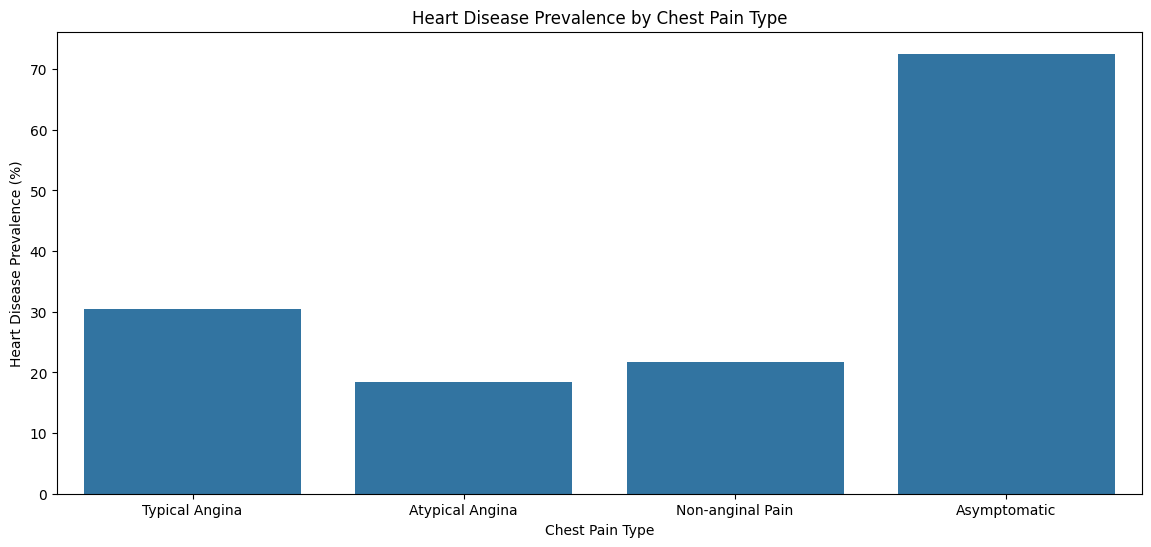

cp
1.0    30.434783
2.0    18.367347
3.0    21.686747
4.0    72.535211
Name: disease, dtype: float64


In [9]:
plt.figure(figsize=(14, 6))

cp_disease_rate = df.groupby('cp')['disease'].mean() * 100
sns.barplot(x=cp_disease_rate.index, y=cp_disease_rate.values)

plt.xticks(ticks=[0, 1, 2, 3], labels=["Typical Angina", "Atypical Angina", "Non-anginal Pain", "Asymptomatic"]
)

plt.ylabel("Heart Disease Prevalence (%)")
plt.xlabel("Chest Pain Type")
plt.title("Heart Disease Prevalence by Chest Pain Type")

plt.show()

print(cp_disease_rate)

**Interpretation:**

- Asymptomatic chest pain (cp=4) shows the highest association with heart disease, with approximately 73% of patients in this category diagnosed with the disease.
- Other chest pain types show substantially lower prevalence rates (18–30%).
- This suggests that asymptomatic chest pain is strongly associated with heart disease in this dataset.


### Q6. Does exercise-induced angina increase heart disease likelihood?

C:\Users\moham\AppData\Local\Temp\ipykernel_2640\4155494054.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.catplot(data=df, x='exang', y='disease', kind='bar', ci=95, height=6, aspect=1.5)


<Figure size 1400x600 with 0 Axes>

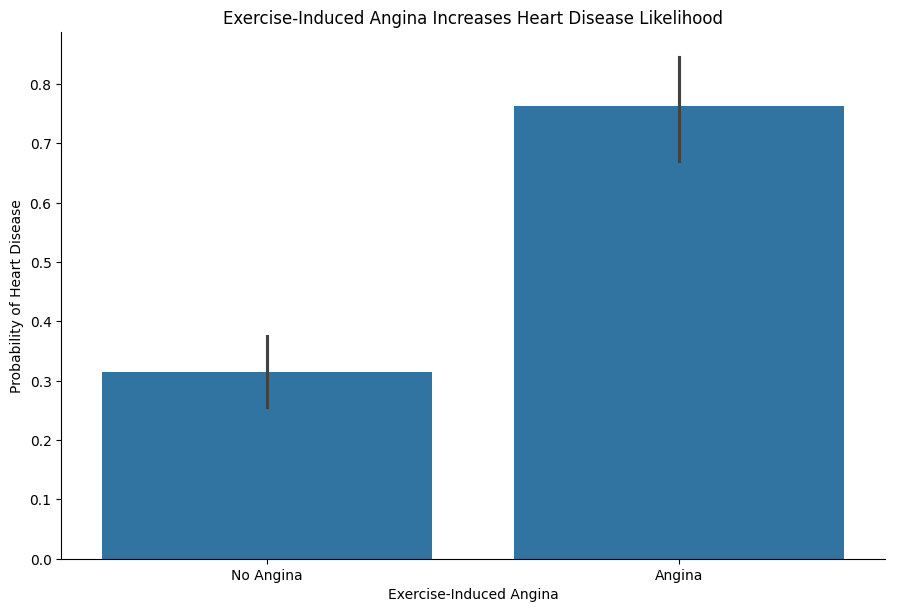


Probability of heart disease:
No Angina: 31.5%
Angina: 76.3%


In [10]:
plt.figure(figsize=(14, 6))


sns.catplot(data=df, x='exang', y='disease', kind='bar', ci=95, height=6, aspect=1.5)
plt.xticks([0, 1], ['No Angina', 'Angina'])
plt.xlabel('Exercise-Induced Angina')
plt.ylabel('Probability of Heart Disease')
plt.title('Exercise-Induced Angina Increases Heart Disease Likelihood')
plt.show()

print("\nProbability of heart disease:")
print(f"No Angina: {df[df['exang']==0]['disease'].mean()*100:.1f}%")
print(f"Angina: {df[df['exang']==1]['disease'].mean()*100:.1f}%")

**Interpretation:**

- Patients with exercise-induced angina have a substantially higher probability of heart disease (76.8%) compared to those without angina (30.9%).
- This large difference suggests a strong association between exercise-induced angina and the presence of heart disease.
- Exercise-induced angina appears to be an important clinical indicator of heart disease in this dataset.


### Q7. How does ST depression (oldpeak) differ between groups? 

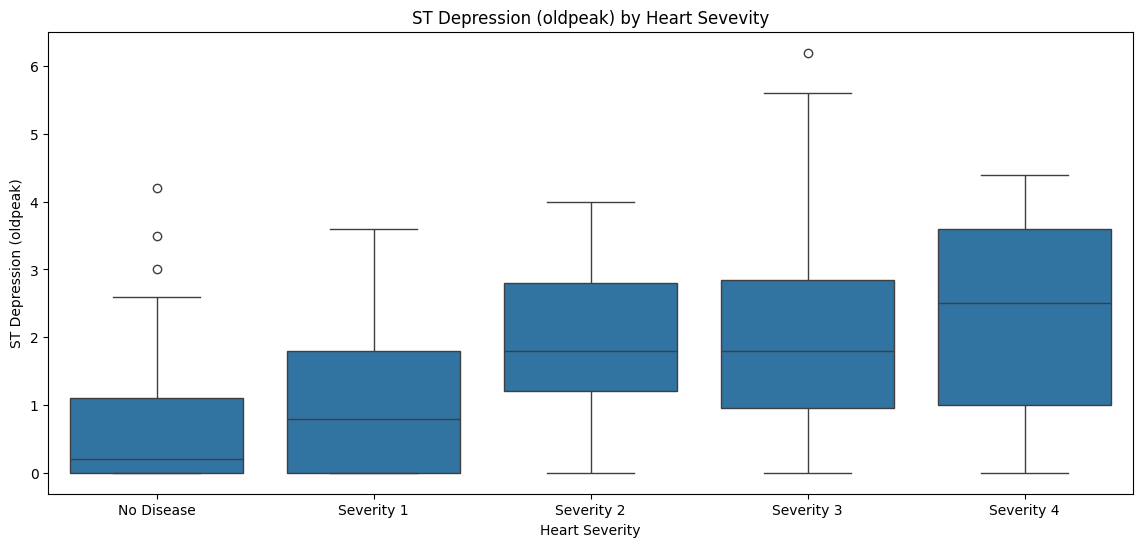

ST DEPRESSION (oldpeak) BY HEART DISEASE

 No Disease (160 Patients):
    Average oldpeak: 0.60
    Range: 0.00 to 4.20

 Severity 1 (54 Patients):
    Average oldpeak: 1.02
    Range: 0.00 to 3.60

 Severity 2 (35 Patients):
    Average oldpeak: 1.80
    Range: 0.00 to 4.00

 Severity 3 (35 Patients):
    Average oldpeak: 1.96
    Range: 0.00 to 6.20

 Severity 4 (13 Patients):
    Average oldpeak: 2.36
    Range: 0.00 to 4.40

No Disease Mean: 0.60
Disease Mean:    1.59


In [11]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='target', y='oldpeak')
plt.title('ST Depression (oldpeak) by Heart Sevevity')
plt.xlabel('Heart Severity')
plt.ylabel('ST Depression (oldpeak)')
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['No Disease', 'Severity 1', 'Severity 2', 'Severity 3', 'Severity 4'])
plt.show()

print('='*40)
print('ST DEPRESSION (oldpeak) BY HEART DISEASE')
print('='*40)

for severity in range(5):
    patients = df[df['target'] == severity]['oldpeak']
    if len(patients)>0:
        if severity == 0:
            label = 'No Disease'
        else:
            label = f'Severity {severity}'

        avg = patients.mean()
        min_value = patients.min()
        max_value = patients.max()

        print(f'\n {label} ({len(patients)} Patients):')
        print(f'    Average oldpeak: {avg:.2f}')
        print(f'    Range: {min_value:.2f} to {max_value:.2f}')

healthy_oldpeak = df[df['disease'] == 0]['oldpeak']
diseased_oldpeak = df[df['disease'] == 1]['oldpeak']

print(f"\nNo Disease Mean: {healthy_oldpeak.mean():.2f}")
print(f"Disease Mean:    {diseased_oldpeak.mean():.2f}")

**Interpretation:**

- ST depression (oldpeak) is higher in patients with heart disease.
- The difference is statistically significant.
- This suggests that ST depression is strongly associated with heart disease severity.


### Q8. Do patients with heart disease achieve lower maximum heart rates?

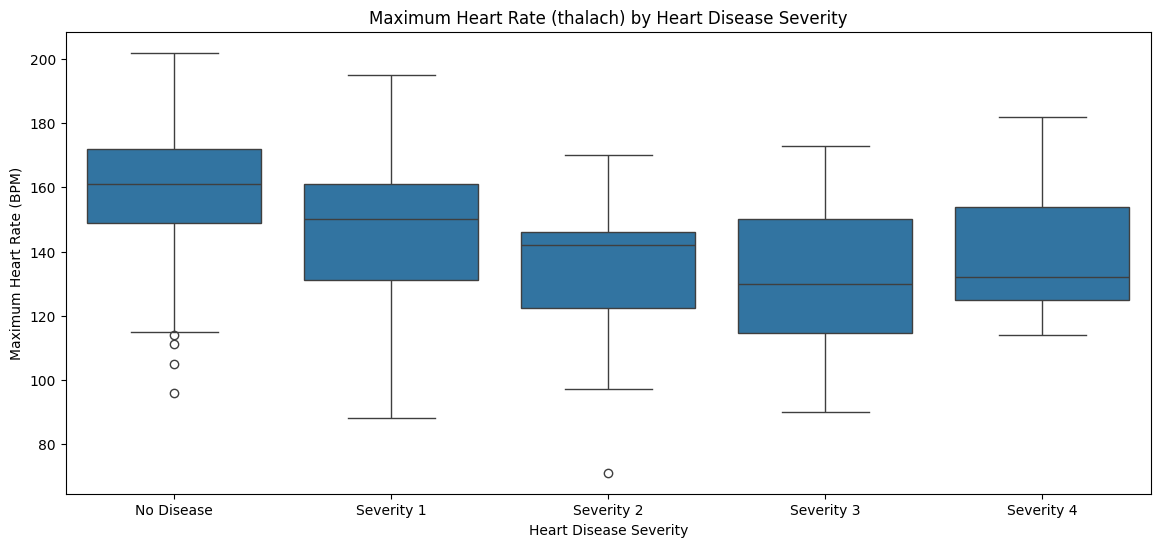

MAXIMUM HEART RATE (thalach) BY DISEASE SEVERITY

 No Disease (160 Patients):
    Average max HR: 159 BPM
    Range: 96 - 202 BPM

 Severity 1 (54 Patients):
    Average max HR: 146 BPM
    Range: 88 - 195 BPM

 Severity 2 (35 Patients):
    Average max HR: 135 BPM
    Range: 71 - 170 BPM

 Severity 3 (35 Patients):
    Average max HR: 132 BPM
    Range: 90 - 173 BPM

 Severity 4 (13 Patients):
    Average max HR: 141 BPM
    Range: 114 - 182 BPM


In [12]:
plt.figure(figsize=(14, 6))

sns.boxplot(data=df, x='target', y='thalach')
plt.title('Maximum Heart Rate (thalach) by Heart Disease Severity')
plt.xlabel('Heart Disease Severity')
plt.ylabel('Maximum Heart Rate (BPM)')
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['No Disease', 'Severity 1', 'Severity 2', 'Severity 3', 'Severity 4'])
plt.show()

print('='*50)
print('MAXIMUM HEART RATE (thalach) BY DISEASE SEVERITY')
print('='*50)

for severity in range(5):
    patients = df[df['target'] == severity]['thalach']
    if len(patients)>0:
        if severity == 0:
            label = 'No Disease'
        else:
            label = f'Severity {severity}'

        avg = patients.mean()
        min_value = patients.min()
        max_value = patients.max()

        print(f'\n {label} ({len(patients)} Patients):')
        print(f'    Average max HR: {avg:.0f} BPM')
        print(f'    Range: {min_value:.0f} - {max_value:.0f} BPM')

**Interpretation:**

- Patients with heart disease achieve lower maximum heart rates compared to those without the disease.
- Maximum heart rate appears to decrease as disease severity increases.
- This suggests a negative association between maximum heart rate and heart disease presence.


### Q9. How does age relate to maximum heart rate for healthy vs diseased patients?

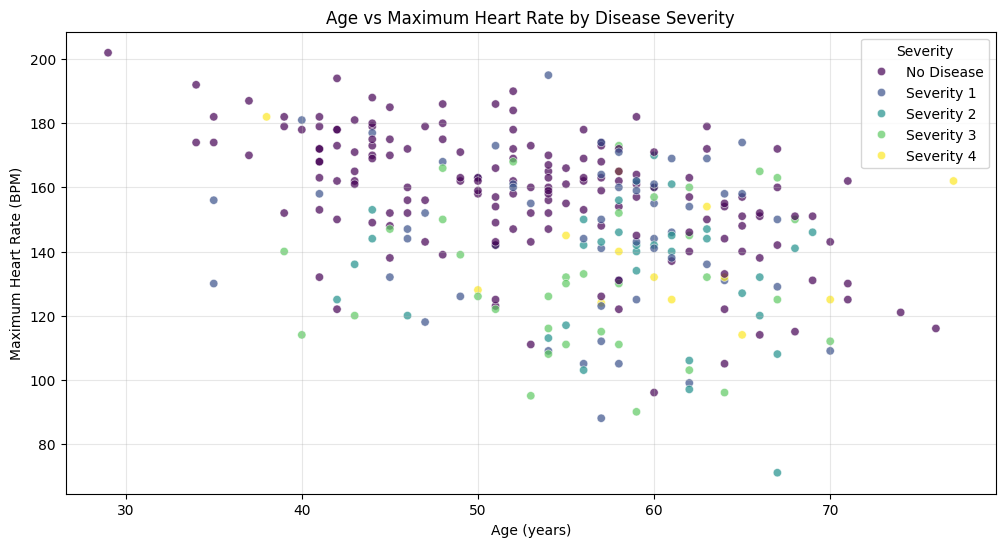

AGE vs HEART RATE

Overall correlation between age and heart rate: -0.39
(Negative value means: older age = lower heart rate)

Average max heart rate: 
  Healthy patients: 159 BPM
  Diseased patients: 139 BPM
  Difference: 19 BPM


In [13]:
plt.figure(figsize=(12, 6))

sns.scatterplot(data=df, x='age', y='thalach', hue='target', palette='viridis', alpha=0.7)
plt.title('Age vs Maximum Heart Rate by Disease Severity')
plt.xlabel('Age (years)')
plt.ylabel('Maximum Heart Rate (BPM)')

ax = plt.gca()
handles, _ = ax.get_legend_handles_labels()
new_labels = ['No Disease', 'Severity 1', 'Severity 2', 'Severity 3', 'Severity 4']
plt.legend(handles, new_labels, title='Severity')

plt.grid(True, alpha=0.3)
plt.show()

print('='*20)
print('AGE vs HEART RATE')
print('='*20)
corr = df['age'].corr(df['thalach'])
print(f'\nOverall correlation between age and heart rate: {corr:.2f}')
print('(Negative value means: older age = lower heart rate)')

healthy = df[df['target'] == 0]['thalach']
disease = df[df['target'] > 0]['thalach']
healthy_avg = healthy.mean()
disease_avg = disease.mean()
print('\nAverage max heart rate: ')
print(f'  Healthy patients: {healthy_avg:.0f} BPM')
print(f'  Diseased patients: {disease_avg:.0f} BPM')
print(f"  Difference: {healthy_avg - disease_avg:.0f} BPM")

### Q10. Does resting blood pressure differ between patients with and without disease?

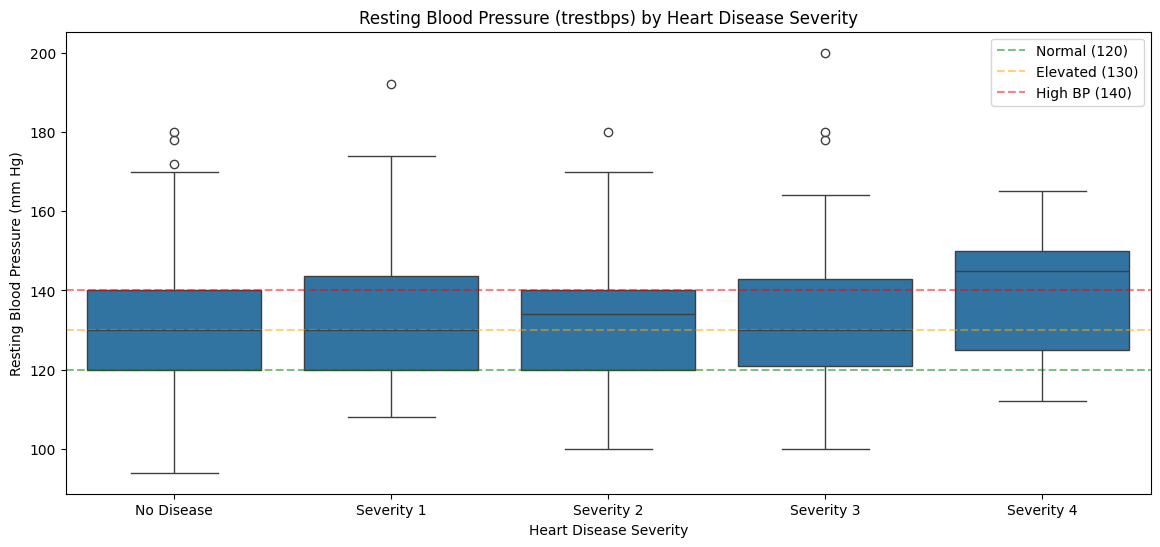

T-statistic: -2.67
P-value: 0.0081


In [14]:
plt.figure(figsize=(14, 6))

sns.boxplot(data=df, x='target', y='trestbps')
plt.title('Resting Blood Pressure (trestbps) by Heart Disease Severity')
plt.xlabel('Heart Disease Severity')
plt.ylabel('Resting Blood Pressure (mm Hg)')
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['No Disease', 'Severity 1', 'Severity 2', 'Severity 3', 'Severity 4'])
plt.axhline(y=120, color='green', linestyle='--', alpha=0.5, label='Normal (120)')
plt.axhline(y=130, color='orange', linestyle='--', alpha=0.5, label='Elevated (130)')
plt.axhline(y=140, color='red', linestyle='--', alpha=0.5, label='High BP (140)')
plt.legend()
plt.show()

healthy = df[df['disease'] == 0]['trestbps']
diseased = df[df['disease'] == 1]['trestbps']

t_stat, p_value = ttest_ind(healthy, diseased)

print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.4f}")

**Interpretation:**

- The average resting blood pressure differs between patients with and without heart disease.
- The difference is statistically significant (p = 0.0081 < 0.05).
- Patients with heart disease tend to show slightly higher resting blood pressure.
- This suggests a potential association between blood pressure and heart disease.


### Q11. Is cholesterol level a distinguishing factor? 

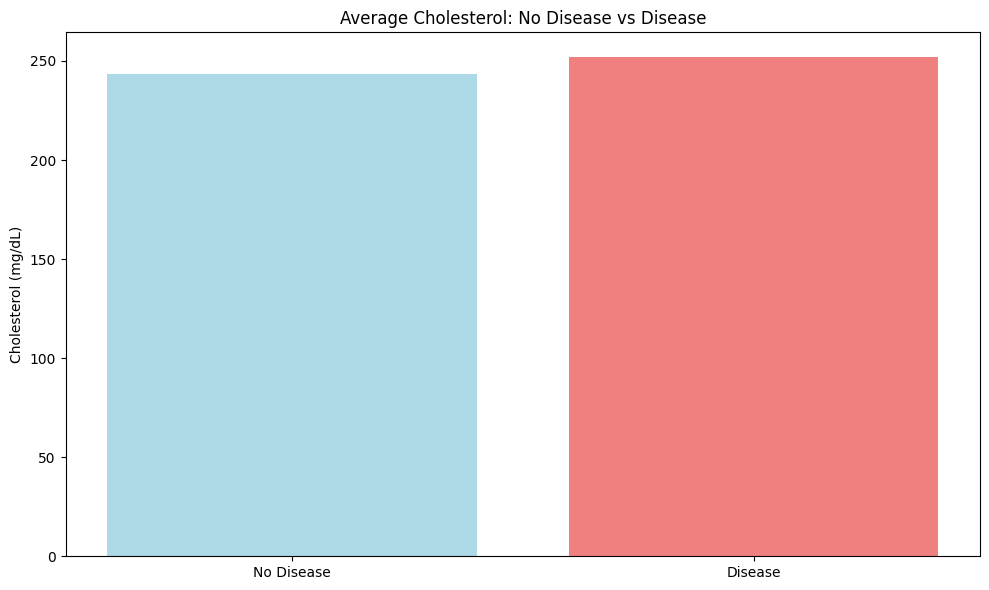

No Disease Mean: 243.5
Disease Mean:    251.9

T-statistic: -1.38
P-value: 0.1676


In [15]:

plt.figure(figsize=(10, 6))
avg_chol = [df[df['target'] == 0]['chol'].mean(), df[df['target'] > 0]['chol'].mean()]

bars = plt.bar(['No Disease', 'Disease'], avg_chol, color=['lightblue', 'lightcoral'])
plt.title('Average Cholesterol: No Disease vs Disease')
plt.ylabel('Cholesterol (mg/dL)')


plt.tight_layout()
plt.show()

healthy_chol = df[df['disease'] == 0]['chol']
diseased_chol = df[df['disease'] == 1]['chol']

print(f"No Disease Mean: {healthy_chol.mean():.1f}")
print(f"Disease Mean:    {diseased_chol.mean():.1f}")
t_stat, p_value = ttest_ind(healthy_chol, diseased_chol)

print(f"\nT-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.4f}")


**Interpretation:**

- The average cholesterol levels are similar between patients with and without heart disease.
- The difference is not statistically significant (p > 0.05).
- This suggests that cholesterol alone may not be a strong distinguishing factor in this dataset.


### Q12. Is high fasting blood sugar linked to heart disease?

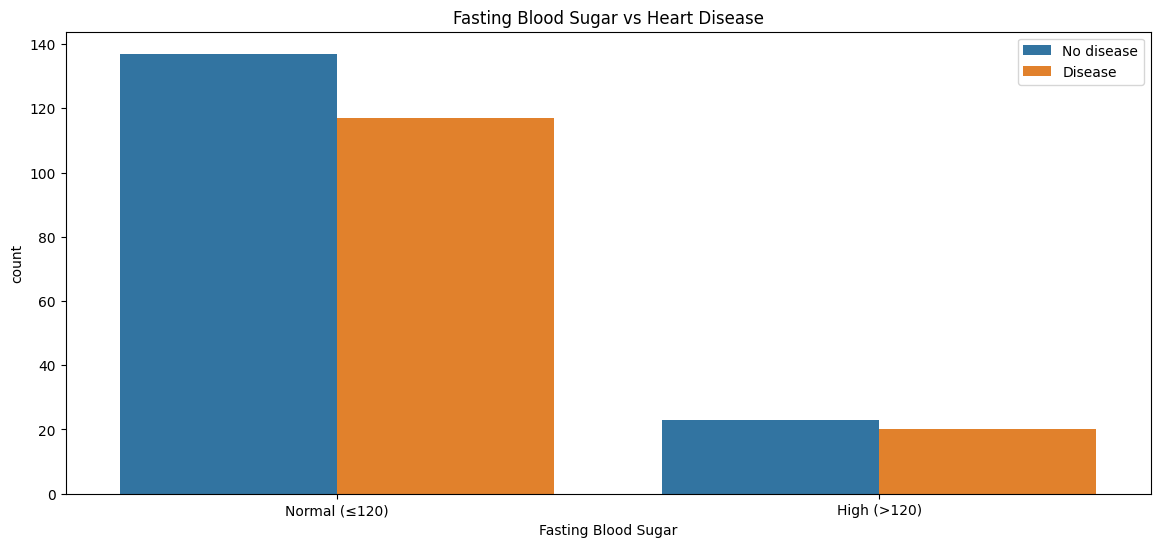

Normal FBS: 46.06%
High FBS:   46.51%


In [16]:
plt.figure(figsize=(14,6))

sns.countplot(data=df, x='fbs', hue='disease')
plt.xticks([0, 1], ['Normal (≤120)', 'High (>120)'])
plt.xlabel('Fasting Blood Sugar')
plt.title('Fasting Blood Sugar vs Heart Disease')
plt.legend(labels= ['No disease', 'Disease'])
plt.show()

fbs_disease_rate = df.groupby('fbs')['disease'].mean() * 100

print(f"Normal FBS: {fbs_disease_rate[0]:.2f}%")
print(f"High FBS:   {fbs_disease_rate[1]:.2f}%")

**Interpretation:**

- Patients with high fasting blood sugar have a heart disease rate of **46.51%**, compared to **46.06%** for patients with normal fasting blood sugar.
- The difference between the two groups is very small.
- This suggests that fasting blood sugar is **not a strong predictor** of heart disease in this dataset.
- Overall, high fasting blood sugar shows only a weak association with heart disease.


### Q13. How do resting ECG results relate to heart disease?

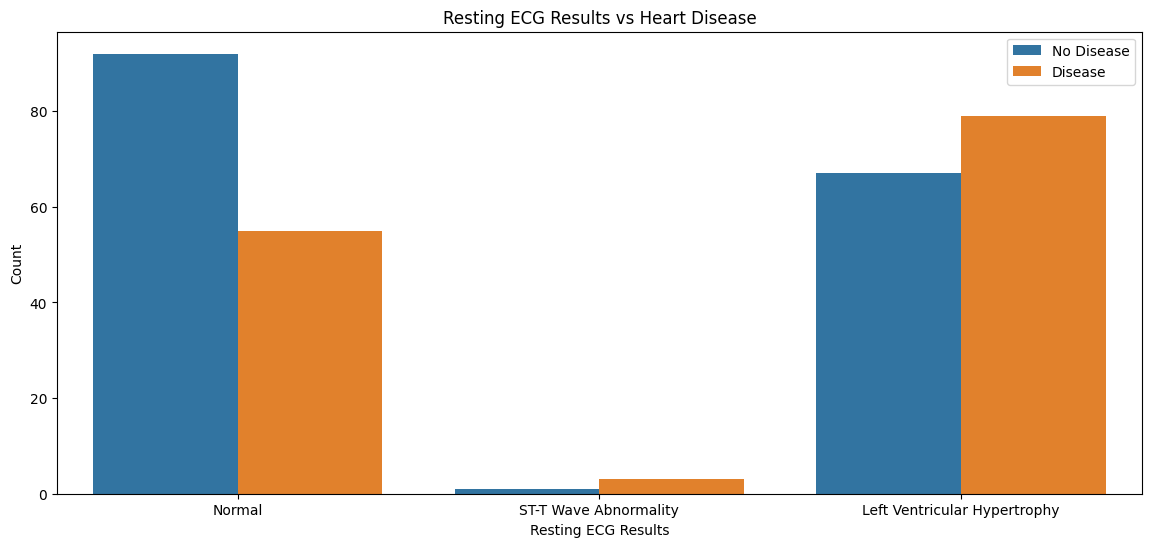

restecg
0.0    37.41
1.0    75.00
2.0    54.11
Name: disease, dtype: float64


In [17]:
plt.figure(figsize=(14, 6))

sns.countplot(data=df, x='restecg', hue='disease')
plt.title('Resting ECG Results vs Heart Disease')
plt.xlabel('Resting ECG Results')
plt.ylabel('Count')
plt.legend(labels=['No Disease', 'Disease'])
plt.xticks(ticks=[0, 1, 2], labels=['Normal', 'ST-T Wave Abnormality', 'Left Ventricular Hypertrophy'])
plt.show()

ecg_disease_rate = df.groupby('restecg')['disease'].mean()*100
print(ecg_disease_rate.round(2))

**Interpretation:**

- The likelihood of heart disease varies across resting ECG categories.
- Patients with ST-T wave abnormalities (1.0) have the highest heart disease rate (75%).
- Patients with left ventricular hypertrophy (2.0) show a moderate rate (54.11%).
- Patients with normal ECG results (0.0) have the lowest rate (37.41%).
- This suggests that abnormal resting ECG results, particularly ST-T wave abnormalities, are associated with a higher likelihood of heart disease.


### Q14. Does the slope of the ST segment differ between groups?

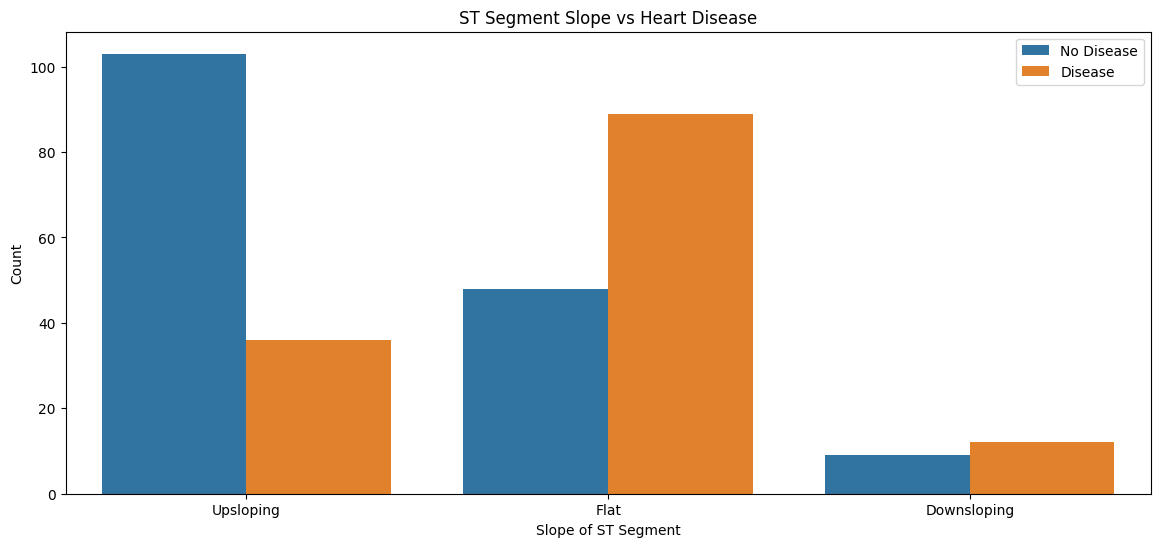

slope
1.0    25.90
2.0    64.96
3.0    57.14
Name: disease, dtype: float64


In [18]:
plt.figure(figsize=(14, 6))

sns.countplot(data=df, x='slope', hue='disease')

plt.title('ST Segment Slope vs Heart Disease')
plt.xlabel('Slope of ST Segment')
plt.ylabel('Count')
plt.legend(labels=['No Disease', 'Disease'])

plt.xticks([0, 1, 2], labels=['Upsloping', 'Flat', 'Downsloping'])
plt.show()

slope_disease_rate = df.groupby('slope')['disease'].mean()*100
print(slope_disease_rate.round(2))

**Interpretation:**

- The likelihood of heart disease differs significantly across ST segment slope categories.
- Patients with a flat slope (2.0) show the highest heart disease rate (65.00%).
- Patients with a downsloping ST segment (3.0) also have a high rate (57.14%).
- Patients with an upsloping ST segment (1.0) have the lowest rate (25.9%).
- These results suggest that abnormal ST segment slopes, particularly a flat slope, are strongly associated with heart disease in this dataset.


### Q15. How does the number of major vessels (ca) affect disease presence?

C:\Users\moham\AppData\Local\Temp\ipykernel_2640\471382135.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=df, x='ca', y='disease', ci=95)


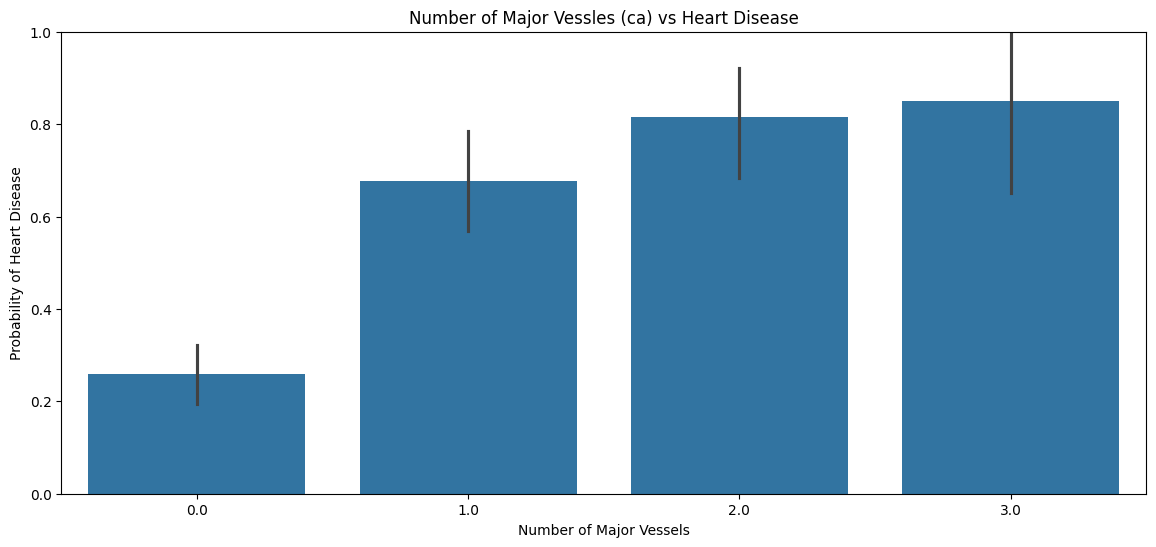

0 vessels: 25.86%
1 vessels: 67.69%
2 vessels: 81.58%
3 vessels: 85.00%


In [19]:
plt.figure(figsize=(14, 6))
sns.barplot(data=df, x='ca', y='disease', ci=95)

plt.title('Number of Major Vessles (ca) vs Heart Disease')
plt.xlabel('Number of Major Vessels')
plt.ylabel('Probability of Heart Disease')
plt.ylim(0, 1)
plt.show()

ca_disease_rate = df.groupby('ca')['disease'].mean()*100
for vessels, rate in ca_disease_rate.items():
    print(f'{int(vessels)} vessels: {rate:.2f}%')

**Interpretation:**

- The probability of heart disease increases sharply as the number of major vessels (ca) increases.
- Patients with 0 vessels show a relatively low disease rate (25.86%).
- Patients with 1 vessel show a much higher rate (67.69%).
- Patients with 2 and 3 vessels show very high probabilities (81.58% and 85.00%).
- This indicates a strong positive relationship between the number of major vessels and heart disease presence.
- Therefore, ca appears to be one of the strongest predictors of heart disease in this dataset.


### Q16. Which thalassemia categories are most associated with heart disease?

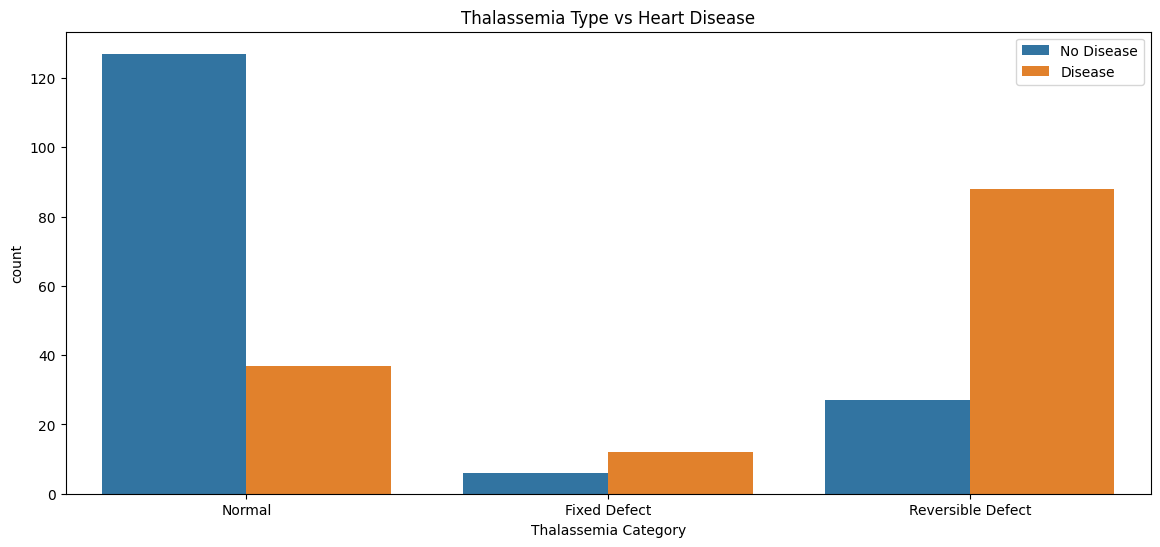

Thal 3: 22.56%
Thal 6: 66.67%
Thal 7: 76.52%


In [20]:
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='thal', hue='disease')
plt.title('Thalassemia Type vs Heart Disease')
plt.xlabel('Thalassemia Category')
plt.legend(labels=['No Disease', 'Disease'])
plt.xticks(ticks=[0, 1, 2], labels=['Normal', 'Fixed Defect', 'Reversible Defect'])
plt.show()

thal_disease_rate = df.groupby('thal')['disease'].mean()*100
for thal_type, rate in thal_disease_rate.items():
    print(f"Thal {int(thal_type)}: {rate:.2f}%")

**Interpretation:**

- The likelihood of heart disease varies significantly across thalassemia categories.
- Patients with normal thal (3) show a low disease rate (22.56%).
- Patients with fixed defect (6) show a much higher rate (66.67%).
- Patients with reversible defect (7) have the highest probability of heart disease (76.52%).
- This indicates a strong association between abnormal thalassemia results and heart disease presence.


### Q17. Which numerical features are most correlated with heart disease?

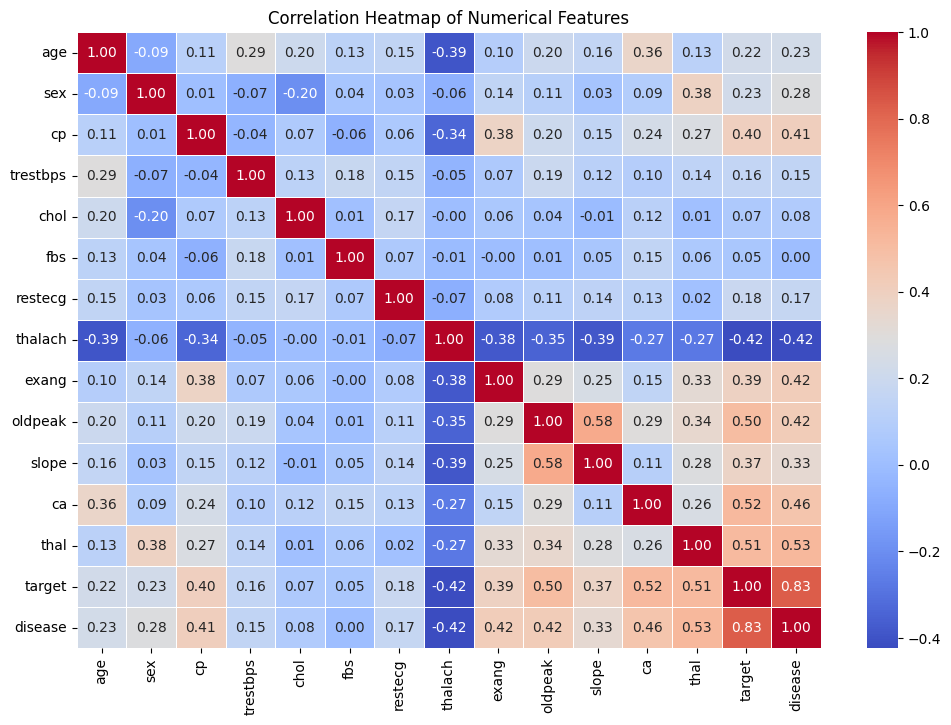

In [21]:
plt.figure(figsize=(12, 8))

correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()


## EDA Summary & Insights

### Q18. Which features appear most informative based on EDA?

**Answer:**

Based on the exploratory data analysis, the most informative features for predicting heart disease appear to be:

- **ca (number of major vessels)** — shows a strong increasing trend in disease probability.
- **thal (thalassemia category)** — abnormal thal results are strongly associated with heart disease.
- **slope (ST segment slope)** — flat and downsloping patterns show higher disease rates.
- **exang (exercise-induced angina)** — patients with angina have significantly higher disease probability.
- **oldpeak (ST depression)** — higher values are associated with increased disease presence.
- **thalach (maximum heart rate)** — negatively correlated with heart disease.

These variables showed the strongest differences in percentages and the highest correlations with the target variable.

---

### Q19. What patterns surprised you or contradicted expectations?

**Answer:**

Some findings were unexpected:

- **Cholesterol (chol)** showed weak correlation with heart disease, despite commonly being considered a major risk factor.
- **Fasting blood sugar (fbs)** also showed only a small difference between groups, suggesting it may not be a strong standalone predictor in this dataset.
- Some ECG categories had high percentages but small sample sizes, which could exaggerate apparent effects.

These results suggest that clinical diagnostic features (such as ca, thal, slope) may be more informative than general health indicators like cholesterol.

---

### Q20. What are the limitations of this dataset?

**Answer:**

Several limitations should be considered:

- **Sample Size:** The dataset is relatively small, which may limit generalizability.
- **Missing Values:** Some variables (e.g., ca and thal) originally contained missing values that required cleaning.
- **Limited Lifestyle Information:** Important risk factors such as smoking habits, diet, physical activity, stress levels, and family history are not included.
- **Measurement Noise:** Clinical measurements may contain variability or diagnostic subjectivity.
- **Binary Outcome Simplification:** Converting disease severity into a binary variable may reduce detailed clinical information.

These limitations suggest that while the dataset is useful for analysis, conclusions should be interpreted cautiously.


## Final Conclusion

This exploratory data analysis identified ca, thal, slope, and exang as the strongest predictors of heart disease. Clinical diagnostic variables appear more informative than general health indicators such as cholesterol or fasting blood sugar. While the dataset provides valuable insights, limitations such as sample size and missing lifestyle factors suggest that further data collection would improve predictive modeling.
